In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score


ROOT = Path("..").resolve()

with open(ROOT / "results/results.json") as f:
    r = json.load(f)

# Text model
text_exp = r['roberta_afc']
flat_preds_text = np.array(text_exp['predictions'])
flat_true_text  = np.array(text_exp['true_labels'])

# Multimodal model
mm_exp = r['wavlm_roberta_afc']

# Dataset
df = pd.read_pickle(ROOT / "data/MMUSED-fallacy/dataset.pkl")
FALLACY_MAP = {
    'AppealtoEmotion': 0, 'AppealtoAuthority': 1, 'AdHominem': 2,
    'FalseCause': 3, 'Slipperyslope': 4, 'Slogans': 5
}
FALLACY_NAMES = {v: k for k, v in FALLACY_MAP.items()}
df['label'] = df['fallacy'].map(FALLACY_MAP)

TARGET = ['13_1988', '22_1996', '25_2000', '31_2004', '46_2020']

# Trouver la position de chaque dialogue dans les prédictions texte (sliding window)
def find_dialogue_offset(flat_true, dialogue_labels):
    n = len(dialogue_labels)
    for start in range(len(flat_true) - n + 1):
        if np.array_equal(flat_true[start:start+n], dialogue_labels):
            return start
    return None

text_results = {}
for did in TARGET:
    expected = df[df['dialogue_id'] == did]['label'].values
    offset = find_dialogue_offset(flat_true_text, expected)
    preds = flat_preds_text[offset:offset+len(expected)]
    text_results[did] = {'true': expected, 'pred': preds}

# Multimodal — reconstruire par dialogue_id
mm_dids   = mm_exp['dialogue_ids']
mm_preds  = np.array(mm_exp['predictions'])
mm_true   = np.array(mm_exp['true_labels'])

mm_results = {}
offset = 0
for did in mm_dids:
    size = len(df[df['dialogue_id'] == did])
    mm_results[did] = {
        'true': mm_true[offset:offset+size],
        'pred': mm_preds[offset:offset+size]
    }
    offset += size

print("Chargement OK")
for did in TARGET:
    f1_t  = f1_score(text_results[did]['true'], text_results[did]['pred'], average='macro', zero_division=0)
    f1_mm = f1_score(mm_results[did]['true'],   mm_results[did]['pred'],   average='macro', zero_division=0)
    print(f"  {did}  text={f1_t:.3f}  multimodal={f1_mm:.3f}  Δ={f1_mm-f1_t:+.3f}")


Chargement OK
  13_1988  text=0.335  multimodal=0.466  Δ=+0.131
  22_1996  text=0.297  multimodal=0.564  Δ=+0.266
  25_2000  text=0.435  multimodal=0.430  Δ=-0.005
  31_2004  text=0.485  multimodal=0.565  Δ=+0.080
  46_2020  text=0.450  multimodal=0.475  Δ=+0.025


dialogue     text  multimodal     delta
 13_1988 0.335389    0.465988  0.130599
 22_1996 0.297178    0.563636  0.266458
 25_2000 0.435185    0.430124 -0.005061
 31_2004 0.485069    0.564815  0.079745
 46_2020 0.449591    0.475076  0.025485

Mean text      : 0.400
Mean multimodal: 0.500
Mean delta     : +0.099


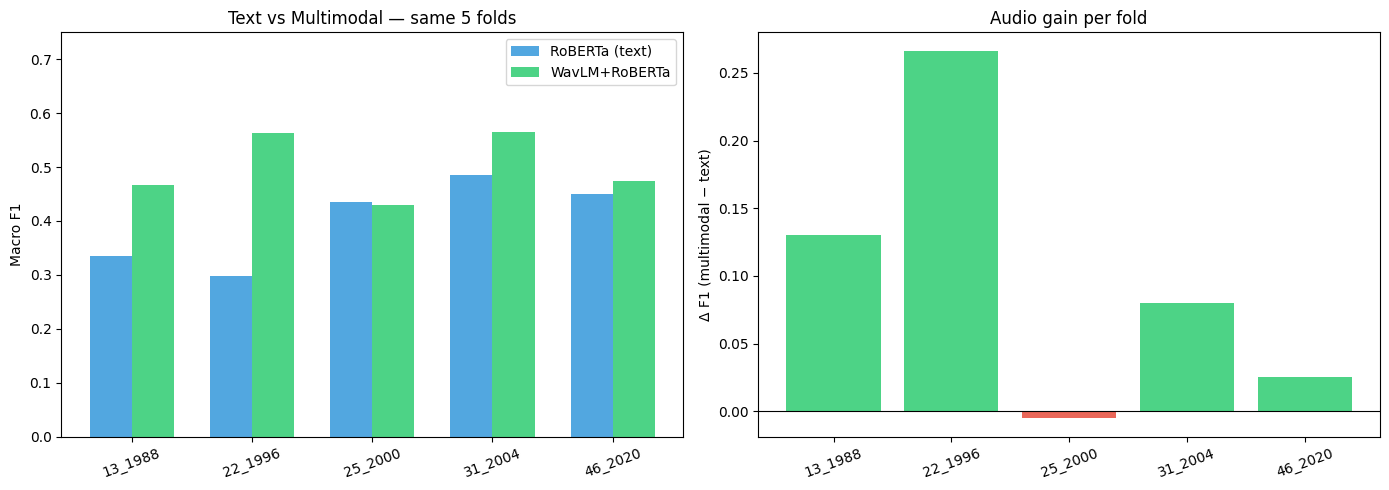

In [3]:
import matplotlib.pyplot as plt

rows = []
for did in TARGET:
    f1_t  = f1_score(text_results[did]['true'], text_results[did]['pred'], average='macro', zero_division=0)
    f1_mm = f1_score(mm_results[did]['true'],   mm_results[did]['pred'],   average='macro', zero_division=0)
    rows.append({'dialogue': did, 'text': f1_t, 'multimodal': f1_mm, 'delta': f1_mm - f1_t})

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))
print(f"\nMean text      : {comp_df['text'].mean():.3f}")
print(f"Mean multimodal: {comp_df['multimodal'].mean():.3f}")
print(f"Mean delta     : {comp_df['delta'].mean():+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(TARGET))
w = 0.35
axes[0].bar(x - w/2, comp_df['text'],       w, label='RoBERTa (text)', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, comp_df['multimodal'], w, label='WavLM+RoBERTa',  color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET, rotation=20)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Text vs Multimodal — same 5 folds')
axes[0].legend()
axes[0].set_ylim(0, 0.75)

colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in comp_df['delta']]
axes[1].bar(x, comp_df['delta'], color=colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(TARGET, rotation=20)
axes[1].set_ylabel('Δ F1 (multimodal − text)')
axes[1].set_title('Audio gain per fold')

plt.tight_layout()
plt.savefig('../results/figures/text_vs_multimodal_5folds.png', dpi=150, bbox_inches='tight')
plt.show()


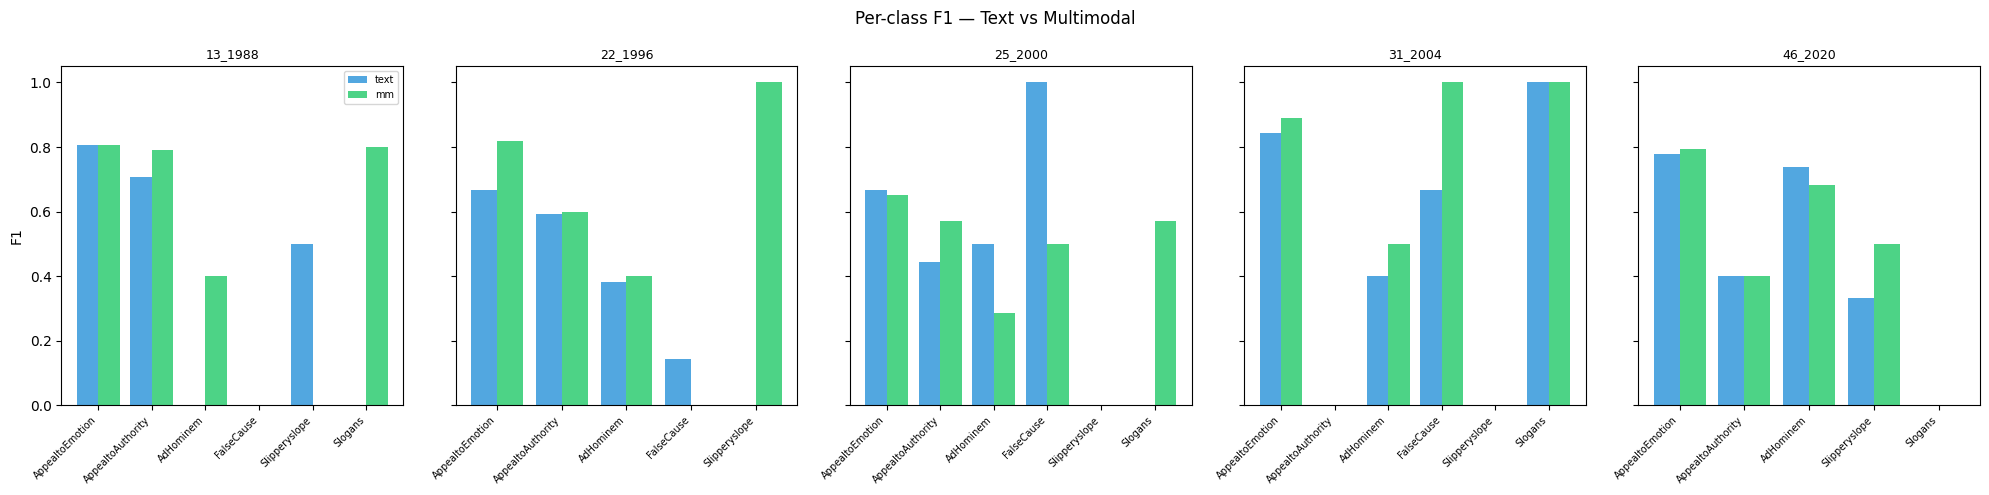

In [4]:
CLASSES = ['AppealtoEmotion','AppealtoAuthority','AdHominem','FalseCause','Slipperyslope','Slogans']

fig, axes = plt.subplots(1, len(TARGET), figsize=(20, 5), sharey=True)

for ax, did in zip(axes, TARGET):
    t_true, t_pred   = text_results[did]['true'],  text_results[did]['pred']
    mm_true, mm_pred = mm_results[did]['true'],     mm_results[did]['pred']

    present = sorted(set(t_true) | set(mm_true))
    names   = [FALLACY_NAMES[c] for c in present]

    f1_t  = f1_score(t_true,  t_pred,  labels=present, average=None, zero_division=0)
    f1_mm = f1_score(mm_true, mm_pred, labels=present, average=None, zero_division=0)

    x = np.arange(len(present))
    ax.bar(x - 0.2, f1_t,  0.4, label='text', color='#3498db', alpha=0.85)
    ax.bar(x + 0.2, f1_mm, 0.4, label='mm',   color='#2ecc71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
    ax.set_title(did, fontsize=9)
    ax.set_ylim(0, 1.05)
    if ax == axes[0]:
        ax.set_ylabel('F1')
        ax.legend(fontsize=7)

plt.suptitle('Per-class F1 — Text vs Multimodal', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/per_class_text_vs_mm.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
did = '25_2000'

t_true,  t_pred  = text_results[did]['true'],  text_results[did]['pred']
mm_true, mm_pred = mm_results[did]['true'],     mm_results[did]['pred']

print(f"=== {did} — distribution des classes ===")
for c, name in FALLACY_NAMES.items():
    n = (t_true == c).sum()
    if n > 0:
        print(f"  {name:<25} n={n}")

print(f"\n=== Erreurs texte ===")
for i, (tr, pr) in enumerate(zip(t_true, t_pred)):
    if tr != pr:
        print(f"  true={FALLACY_NAMES[tr]:<25} pred={FALLACY_NAMES[pr]}")

print(f"\n=== Erreurs multimodal ===")
for i, (tr, pr) in enumerate(zip(mm_true, mm_pred)):
    if tr != pr:
        print(f"  true={FALLACY_NAMES[tr]:<25} pred={FALLACY_NAMES[pr]}")

# Clips de ce dialogue dans l'audit
audit = pd.read_csv(ROOT / "results/whisper_audit.csv").fillna("")
fold_audit = audit[audit['dialogue_id'] == did]
print(f"\n=== Audit whisper {did} ===")
print(f"  Total clips : {len(fold_audit)}")
print(f"  WER moyen   : {fold_audit['wer'].mean():.3f}")
print(f"  WER médian  : {fold_audit['wer'].median():.3f}")


=== 25_2000 — distribution des classes ===
  AppealtoEmotion           n=21
  AppealtoAuthority         n=3
  AdHominem                 n=6
  FalseCause                n=3
  Slipperyslope             n=2
  Slogans                   n=5

=== Erreurs texte ===
  true=AppealtoEmotion           pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AdHominem                 pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=Slogans                   pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=

In [5]:
import sys
sys.path.insert(0, str(ROOT))

from src.data.context_dataset import ContextMMUSEDFallacy
from mamkit.data.datasets import InputMode
import matplotlib.pyplot as plt

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 15529.46it/s]


=== 25_2000 — longueur des inputs RoBERTa (context+snippet) ===
  Min    : 33
  Max    : 189
  Moyen  : 80.8
  Médian : 86
  > 512  : 0 / 40
  > 400  : 0 / 40



Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 15748.05it/s]


=== 25_2000 — longueur SANS contexte ===
  Max    : 73
  Moyen  : 26.1


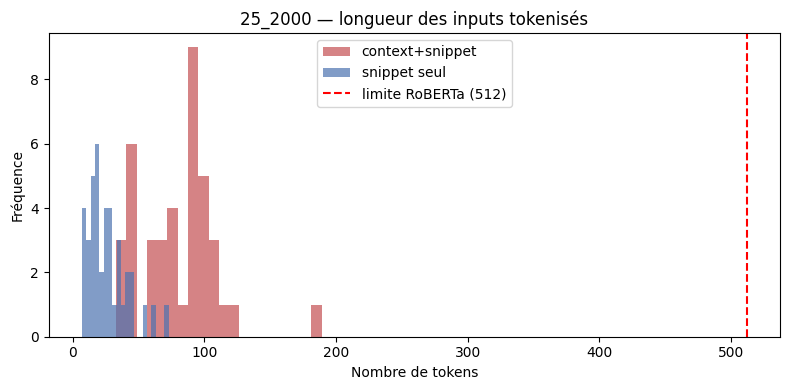

In [6]:
from transformers import AutoTokenizer

tokenizer_rb = AutoTokenizer.from_pretrained('roberta-base')

# Reconstruire les textes context+snippet pour 25_2000
from src.data.context_dataset import ContextMMUSEDFallacy
from mamkit.data.datasets import InputMode

loader_ctx = ContextMMUSEDFallacy(
    task_name='afc',
    input_mode=InputMode.TEXT_ONLY,
    base_data_path=ROOT / 'data',
)

fold_df = loader_ctx.data[loader_ctx.data['dialogue_id'] == '25_2000'].copy()

# Longueur en tokens pour chaque snippet+contexte
fold_df['n_tokens'] = fold_df['snippet'].apply(
    lambda t: len(tokenizer_rb(t, truncation=False)['input_ids'])
)

print(f"=== 25_2000 — longueur des inputs RoBERTa (context+snippet) ===")
print(f"  Min    : {fold_df['n_tokens'].min()}")
print(f"  Max    : {fold_df['n_tokens'].max()}")
print(f"  Moyen  : {fold_df['n_tokens'].mean():.1f}")
print(f"  Médian : {fold_df['n_tokens'].median():.0f}")
print(f"  > 512  : {(fold_df['n_tokens'] > 512).sum()} / {len(fold_df)}")
print(f"  > 400  : {(fold_df['n_tokens'] > 400).sum()} / {len(fold_df)}")
print()

# Comparer avec les snippets sans contexte
loader_plain = __import__('mamkit.data.datasets', fromlist=['MMUSEDFallacy']).MMUSEDFallacy(
    task_name='afc',
    input_mode=InputMode.TEXT_ONLY,
    base_data_path=ROOT / 'data',
)
plain_df = loader_plain.data[loader_plain.data['dialogue_id'] == '25_2000'].copy()
plain_df['n_tokens'] = plain_df['snippet'].apply(
    lambda t: len(tokenizer_rb(t, truncation=False)['input_ids'])
)

print(f"=== 25_2000 — longueur SANS contexte ===")
print(f"  Max    : {plain_df['n_tokens'].max()}")
print(f"  Moyen  : {plain_df['n_tokens'].mean():.1f}")

# Distribution visuelle
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fold_df['n_tokens'], bins=20, color='#C44E52', alpha=0.7, label='context+snippet')
ax.hist(plain_df['n_tokens'], bins=20, color='#4C72B0', alpha=0.7, label='snippet seul')
ax.axvline(512, color='red', linestyle='--', linewidth=1.5, label='limite RoBERTa (512)')
ax.set_xlabel('Nombre de tokens')
ax.set_ylabel('Fréquence')
ax.set_title('25_2000 — longueur des inputs tokenisés')
ax.legend()
plt.tight_layout()
plt.show()
